# 02 — Feature Engineering & Preprocessing

**Project:** Insurance Fraud Detection  
**Input:** [Kaggle - Insuance Claims](https://www.kaggle.com/code/meddhiaeddinedabbech/fraud-detection-in-insurance-claims/input?select=insurance_claims.csv)   
**Goal:** Build a rich, model-ready feature set through encoding, derived features, outlier treatment, and feature selection.

---
## Table of Contents
1. [Setup & Data Import](#1)
2. [Encoding Categorical Variables](#2)
3. [Creating New Features](#3)
4. [Outlier Treatment](#4)
5. [Feature Selection](#5)
6. [Building Feature Sets & Export](#6)

## 1. Setup & Data Import <a id='1'></a>

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../Dataset/insurance_claims.csv')

# --- Data Cleaning as per 01_Exploratory_Data_Analysis_(EDA) ---

# Handling missing values in authorities_contacted
mask = (df['authorities_contacted'].isnull()) & (df['police_report_available'] == 'YES')
df.loc[mask, 'authorities_contacted'] = 'Police'

df['authorities_contacted'] = df['authorities_contacted'].fillna('Unknown')

# Handling missing values in collision_type
missing_mask = df['collision_type'] == '?'
probs = df['collision_type'].replace('?', np.nan).value_counts(normalize=True)

df.loc[missing_mask, 'collision_type'] = np.random.choice(
    probs.index, size=missing_mask.sum(), p=probs.values
)

# Handling missing values in police_report_available & property_damage
df['police_report_available'] = df['police_report_available'].replace('?', 'Unknown')
df['property_damage'] = df['property_damage'].replace('?', 'Unknown')
df['umbrella_limit'] = df['umbrella_limit'].replace(-1000000, 0)

# Converting dates
df['incident_date'] = pd.to_datetime(df['incident_date'])
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])

# Dropping columns except total_claim_amount
df.drop(columns=[
    '_c39', 'policy_number', 'insured_zip', 'incident_location'
] , inplace=True)

print(f"Clean dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# Encoding target
df['fraud_reported'] = (df['fraud_reported'] == 'Y').astype(int)

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()

Clean dataset: 1000 rows, 36 columns
Dataset: 1000 rows, 36 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_bind_date             1000 non-null   datetime64[ns]
 3   policy_state                 1000 non-null   object        
 4   policy_csl                   1000 non-null   object        
 5   policy_deductable            1000 non-null   int64         
 6   policy_annual_premium        1000 non-null   float64       
 7   umbrella_limit               1000 non-null   int64         
 8   insured_sex                  1000 non-null   object        
 9   insured_education_level      1000 non-null   object        
 10  insured_occupation           1000 non-nul

## 2. Encoding Categorical Variables <a id='2'></a>

In [135]:
df['authorities_contacted'].value_counts()

,count
authorities_contacted,
Police,320
Fire,223
Other,198
Ambulance,196
Unknown,63


In [136]:
# --- Binary encoding for binary categoricals ---
df['insured_sex'] = (df['insured_sex'] == 'FEMALE').astype(int)  # 0=Male, 1=Female
df['property_damage'] = df['property_damage'].map({'YES': 1, 'NO': 0, 'Unknown': -1})
df['police_report_available'] = df['police_report_available'].map({'YES': 1, 'NO': 0, 'Unknown': -1})

# Grouping auto make into 2 categories
def group_auto_make(make):
    luxury = ['Mercedes', 'BMW', 'Audi', 'Porsche', 'Lexus', 'Jeep', 'Land Rover', 'Suburu']
    if make in luxury:
        return 'luxury'
    return 'mainstream'

df['auto_make_group'] = df['auto_make'].apply(group_auto_make)
df['luxury_auto_make_flag'] = (df['auto_make_group'] == 'luxury').astype(int)

# Drop raw high-cardinality columns now replaced by binary column
df.drop(columns=['auto_make_group', 'auto_make', 'auto_model'], inplace=True)

print("Binary encoding done")

Binary encoding done


In [137]:
# --- High-cardinality grouping before one-hot encoding ---
def group_hobby(hobby):
    high_risk = ['bungie-jumping', 'base-jumping', 'skydiving', 'paintball']
    active = ['exercise', 'cross-fit', 'basketball', 'golf', 'hiking', 'polo', 'camping', 'kayaking', 'yoga']
    if hobby in high_risk:
        return 'high_risk'
    elif hobby in active:
        return 'active'
    else:
        return 'leisure'

def group_occupation(occ):
    white_collar = ['exec-managerial', 'prof-specialty', 'tech-support', 'adm-clerical', 'protective-serv', 'sales']
    blue_collar = ['craft-repair', 'machine-op-inspct', 'transport-moving', 'handlers-cleaners', 'farming-fishing', 'priv-house-serv']
    if occ in white_collar:
        return 'white_collar'
    elif occ in blue_collar:
        return 'blue_collar'
    else:
        return 'other'

df['hobby_group'] = df['insured_hobbies'].apply(group_hobby)
df['occupation_group'] = df['insured_occupation'].apply(group_occupation)

# Drop raw high-cardinality columns now replaced by groups
df.drop(columns=['insured_hobbies', 'insured_occupation'], inplace=True)
print("Grouping done")

Grouping done


In [138]:
# --- One-hot encoding for remaining categoricals ---
categorical_cols = df.select_dtypes('object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ['incident_date', 'policy_bind_date']]

print(f"One-hot encoding: {categorical_cols}")

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"After encoding: {df.shape[1]} columns")

One-hot encoding: ['policy_state', 'policy_csl', 'insured_education_level', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'hobby_group', 'occupation_group']
After encoding: 66 columns


## 3. Creating New Features <a id='3'></a>

In [139]:
# --- Time-based features ---

# Days between policy binding and incident
df['days_bind_to_incident'] = (df['incident_date'] - df['policy_bind_date']).dt.days
print("Negative values (incident before bind date):", (df['days_bind_to_incident'] < 0).sum())

# Incident day of week (Monday=0, Sunday=6)
df['incident_dow'] = df['incident_date'].dt.dayofweek
df['is_weekend'] = df['incident_dow'].isin([5, 6]).astype(int)

# Night incident (before 6am or after 6pm)
df['is_night_incident'] = df['incident_hour_of_the_day'].apply(lambda x: 1 if x < 6 or x >= 18 else 0)

# Auto age at time of incident
df['auto_age'] = df['incident_date'].dt.year - df['auto_year']
df['is_new_auto'] = (df['auto_age'] <= 3).astype(int)

# Drop raw date columns
df.drop(columns=['incident_date', 'policy_bind_date', 'auto_year'], inplace=True)

print("Time features created")

Negative values (incident before bind date): 1
Time features created


In [140]:
# --- Claim ratio features ---

# Ratio of each sub-claim to sum of all three
df['injury_claim_ratio'] = df['injury_claim'] / df['total_claim_amount'].replace(0, 1)
df['property_claim_ratio'] = df['property_claim'] / df['total_claim_amount'].replace(0, 1)
df['vehicle_claim_ratio'] = df['vehicle_claim'] / df['total_claim_amount'].replace(0, 1)

# Average claim per vehicle involved
df['claim_per_vehicle'] = df['total_claim_amount'] / df['number_of_vehicles_involved'].replace(0, 1)

print("Claim ratio features created")

Claim ratio features created


In [141]:
# --- Behavioural / risk flags (from EDA insights) ---

# Report mismatch: police contacted but no report available
df['report_mismatch'] = (
    df.get('authorities_contacted_Police', 0) == 1) & (df['police_report_available'] != 1
).astype(int)

# Umbrella flag
df['has_umbrella'] = (df['umbrella_limit'] > 0).astype(int)

# New/recent customer
df['is_new_customer'] = (df['months_as_customer'] < 12).astype(int)

print("Risk flag features created")

Risk flag features created


In [142]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.000000,115.750000,199.500000,276.250000,4.790000e+02
age,1000.0,3.894800e+01,9.140287e+00,19.000000,32.000000,38.000000,44.000000,6.400000e+01
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.000000,500.000000,1000.000000,2000.000000,2.000000e+03
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.330000,1089.607500,1257.200000,1415.695000,2.047590e+03
umbrella_limit,1000.0,1.102000e+06,2.296709e+06,0.000000,0.000000,0.000000,0.000000,1.000000e+07
insured_sex,1000.0,5.370000e-01,4.988786e-01,0.000000,0.000000,1.000000,1.000000,1.000000e+00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.000000,0.000000,0.000000,51025.000000,1.005000e+05
capital-loss,1000.0,-2.679370e+04,2.810410e+04,-111100.000000,-51500.000000,-23250.000000,0.000000,0.000000e+00
incident_hour_of_the_day,1000.0,1.164400e+01,6.951373e+00,0.000000,6.000000,12.000000,17.000000,2.300000e+01
number_of_vehicles_involved,1000.0,1.839000e+00,1.018880e+00,1.000000,1.000000,1.000000,3.000000,4.000000e+00


## 4. Outlier Treatment <a id='4'></a>

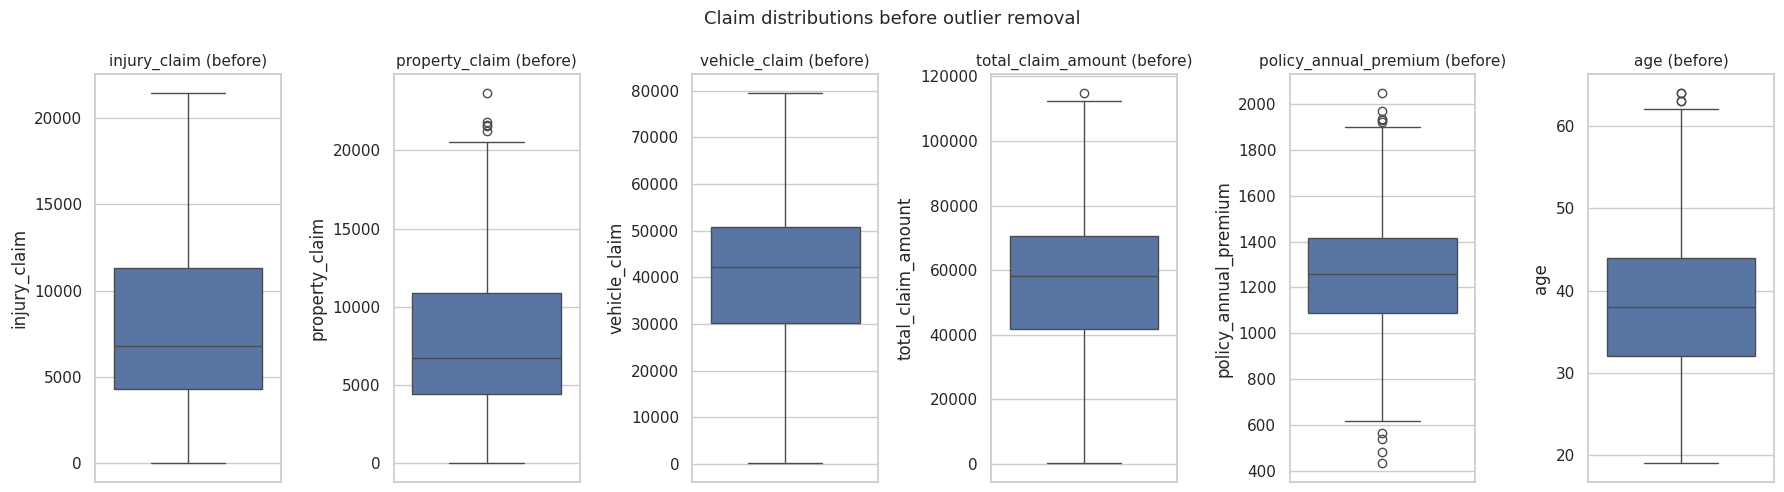

Rows removed: 20 (2.0%)
Remaining rows: 980


In [143]:
initial_rows = len(df)

# Remove claim with incident date before policy bind date
df = df[df['days_bind_to_incident'] >= 0]

# IQR-based outlier removal
outlier_cols = ['injury_claim', 'property_claim', 'vehicle_claim', 'total_claim_amount', 'policy_annual_premium', 'age']
N = 1.5

fig, axs = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axs[i])
    axs[i].set_title(f'{col} (before)', fontsize=11)
plt.suptitle('Claim distributions before outlier removal', fontsize=13)
plt.tight_layout()
plt.show()

for col in outlier_cols:
    q1 = np.percentile(df[col], 25)
    q3 = np.percentile(df[col], 75)
    upper = q3 + N * (q3 - q1)
    lower = q1 - N * (q3 - q1)
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f"Rows removed: {initial_rows - len(df)} ({100*(initial_rows-len(df))/initial_rows:.1f}%)")
print(f"Remaining rows: {len(df)}")

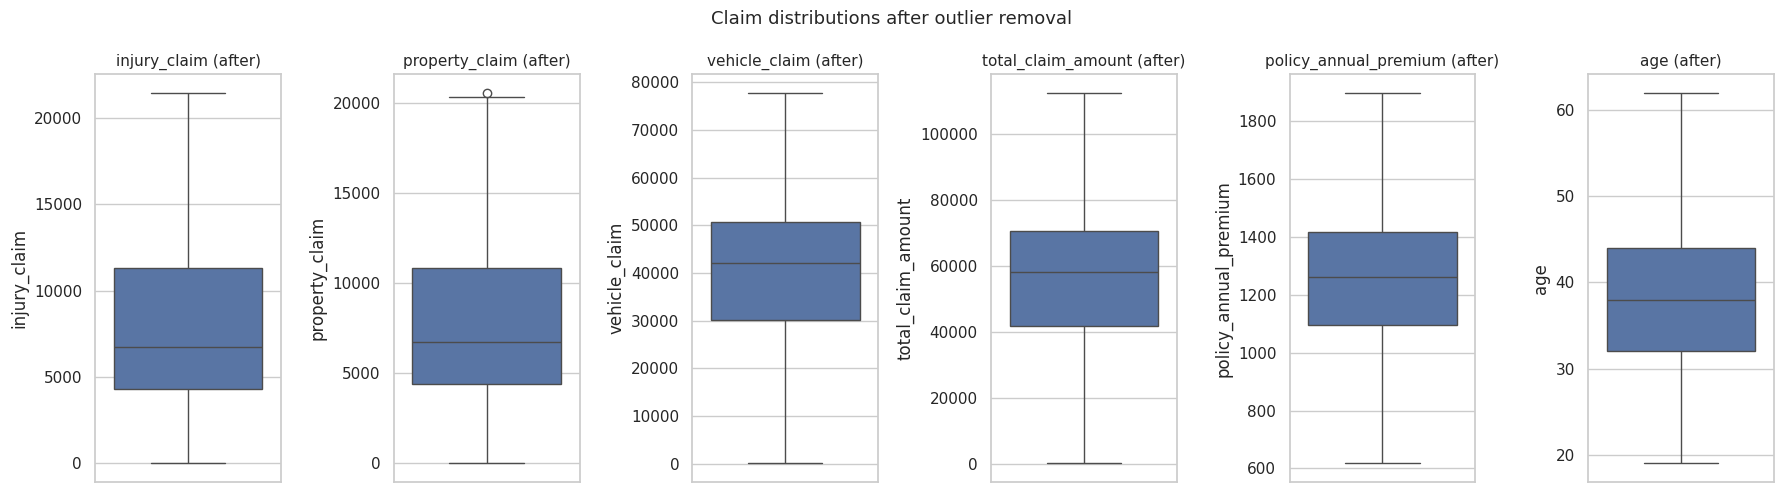

In [144]:
# Verify outlier removal
fig, axs = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axs[i])
    axs[i].set_title(f'{col} (after)', fontsize=11)
plt.suptitle('Claim distributions after outlier removal', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Selection <a id='5'></a>

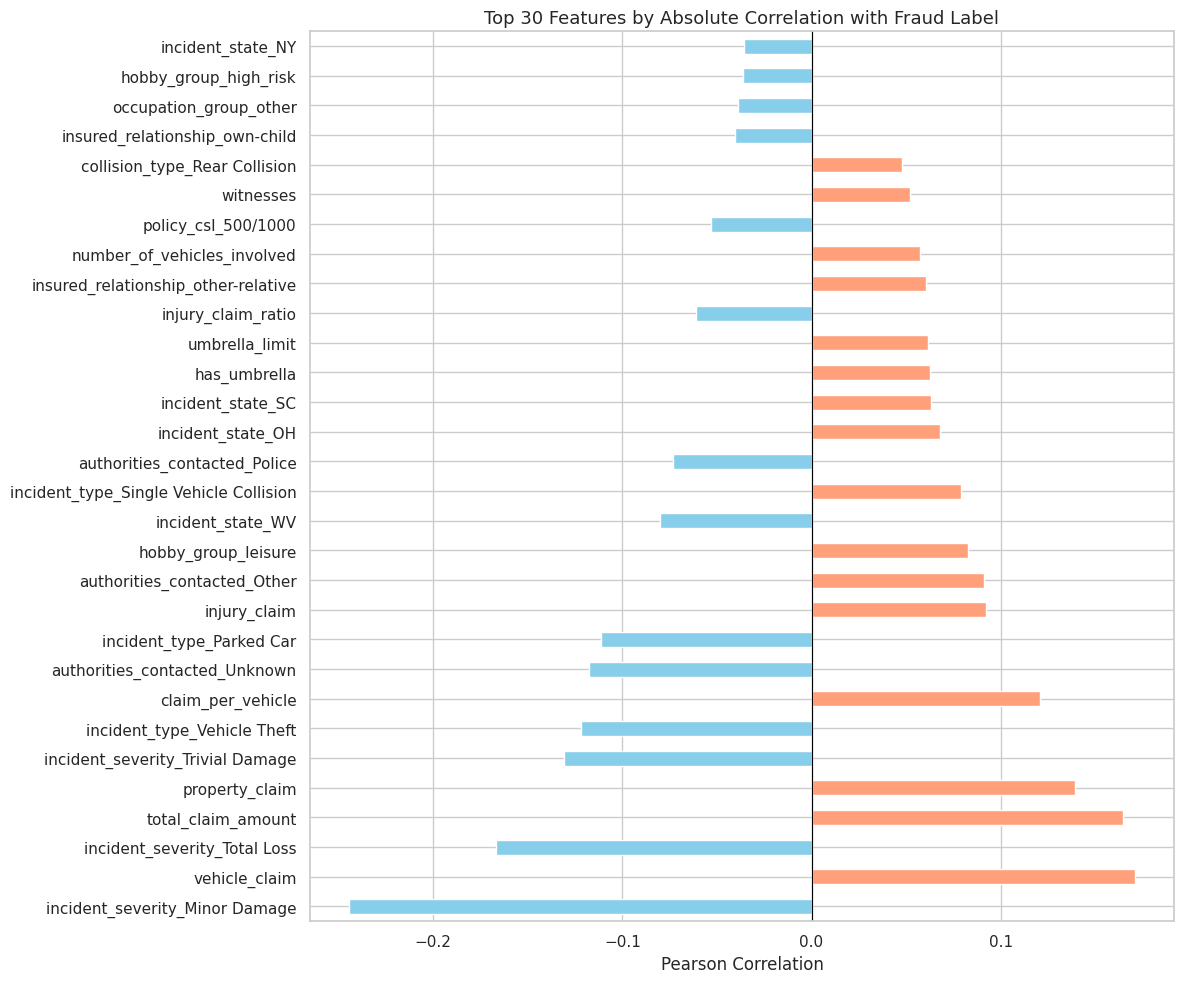

In [145]:
# Correlation with target
y = df['fraud_reported']
X = df.drop(columns=['fraud_reported'])

corr_with_target = X.corrwith(y).sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 10))
corr_with_target.head(30).plot(kind='barh',
    color=['lightsalmon' if x > 0 else 'skyblue' for x in corr_with_target.head(30)])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 30 Features by Absolute Correlation with Fraud Label', fontsize=13)
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

In [146]:
# Flag highly correlated pairs
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] >= 0.6]

for col1, col2, val in sorted(high_corr, key=lambda x: -x[2]):
    print(f"{col1} — {col2}: {val:.2f}")

vehicle_claim — total_claim_amount: 0.98
has_umbrella — umbrella_limit: 0.96
age — months_as_customer: 0.92
claim_per_vehicle — incident_type_Single Vehicle Collision: 0.89
property_claim — total_claim_amount: 0.81
injury_claim — total_claim_amount: 0.80
is_weekend — incident_dow: 0.79
vehicle_claim — property_claim: 0.74
report_mismatch — authorities_contacted_Police: 0.72
vehicle_claim — injury_claim: 0.72
claim_per_vehicle — total_claim_amount: 0.68
incident_type_Single Vehicle Collision — number_of_vehicles_involved: 0.68
claim_per_vehicle — vehicle_claim: 0.67
is_new_auto — auto_age: 0.67
vehicle_claim_ratio — injury_claim_ratio: 0.64


In [147]:
# --- Tree based models ---
# They can handle fragility, correlated features, etc.
#  Decision Tree, Random Forest, XGBoost

tree_features = X.drop(columns=[
    'vehicle_claim', 'age', 'umbrella_limit', 'claim_per_vehicle'
]).columns.tolist()

# --- Linear models ---
# They need linearity, feature independence (sensitive to scale and relevance)
# Logistic Regression, SVM

highly_correlated_target = corr_with_target.head(45).index.tolist()
highly_correlated_self = [
    'vehicle_claim', 'injury_claim', 'property_claim', 'is_weekend',
    'age', 'has_umbrella', 'claim_per_vehicle', 'report_mismatch',
    'injury_claim_ratio'
]

linear_features = [
    item for item in highly_correlated_target if item not in highly_correlated_self
]

# --- Distance-based models ---
# Needs the cleanest, most discriminating set
# KNN

highly_correlated_target = corr_with_target.head(35).index.tolist()
highly_correlated_self = [
    'vehicle_claim', 'injury_claim', 'property_claim', 'is_weekend',
    'age', 'has_umbrella', 'claim_per_vehicle', 'report_mismatch',
    'is_new_auto', 'injury_claim_ratio', 'incident_type_Single Vehicle Collision'
]

dist_features = [
    item for item in highly_correlated_target if item not in highly_correlated_self
]

## 6. Building Feature Sets & Export <a id='6'></a>

In [148]:
# Build and scale feature matrices

X_tree = X[tree_features] # Doesn't need scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_linear = X[linear_features]
X_dist = X[dist_features]

X_linear_scaled = pd.DataFrame(scaler.fit_transform(X_linear), columns=X_linear.columns)
X_dist_scaled = pd.DataFrame(scaler.fit_transform(X_dist), columns=X_dist.columns)

print("Feature sets ready:")
print(f"  X_tree for tree based modelling: {X_tree.shape}")
print(f"  X_linear for linear models: {X_linear.shape}")
print(f"  X_dist for distance based models: {X_dist.shape}")

Feature sets ready:
  X_tree for tree based modelling: (980, 71)
  X_linear for linear models: (980, 37)
  X_dist for distance based models: (980, 28)


In [150]:
# Save processed datasets for modelling notebook
import os
os.makedirs('../Dataset/Processed', exist_ok=True)

X_tree['fraud_reported'] = y.values
X_linear_scaled['fraud_reported'] = y.values
X_dist_scaled['fraud_reported'] = y.values

X_tree.to_csv('../Dataset/Processed/X_tree.csv', index=False)
X_linear_scaled.to_csv('../Dataset/Processed/X_linear_scaled.csv', index=False)
X_dist_scaled.to_csv('../Dataset/Processed/X_dist_scaled.csv', index=False)

print("Processed datasets saved to Dataset/Processed/")

Processed datasets saved to Dataset/Processed/


/tmp/ipykernel_519/2850733800.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_tree['fraud_reported'] = y.values


**Summary of Feature Engineering**

Three feature sets exported for modelling for which we excluded columns that are highly correlated with each other (picked one of the two)
- `X_tree`: All features except corr >= 0.85
- `X_linear_scaled`: Top 45 features highly correlated with target except corr >= 0.7
- `X_dist_scaled`: Top 35 features highly correlated with target except corr >= 0.6

**Next step: `03_Modelling.ipynb`**